<details>
<summary><b>Info</b></summary>

**Last Execution:** 2026-08-05

| Package | Version |
|---------|---------|
| **nnsight** | **0.8** |
| Python | 3.12.13 |
| torch | 2.13.0+cu126 |
| transformers | 5.15.0 |

</details>

# Gaze Heads

## Introduction

👁️ Give a vision-language model a six-panel comic strip and ask what is happening in the third
panel. It answers about the third panel. Something inside it has to be *selecting* that panel —
and in a transformer, selection is attention.

**Gaze heads** are the attention heads doing it: the small set whose attention lands on whatever
panel the model is currently talking about. They are found with no training and no labels — one
forward pass per question, reading where attention goes — and once found they act as a steering
handle. Push those heads at a different panel and the model describes *that* panel instead, from
the same image and the same question.

The whole method is two ideas:

1. **Discovery.** Ask about panel $k$ and measure how much attention the final prompt token puts
   on panel $k$'s image tokens. A head that does this for every $k$ is tracking the query.
2. **Steering.** Attention masks are added to the attention logits *before* the softmax. So a
   per-head additive bias on the mask — $+b$ on the target panel's image tokens, $-b$ on the
   rest — redirects exactly the heads you choose, and nothing else.

📗 [*Gaze Heads: How VLMs Look at What They Describe*](https://arxiv.org/abs/2606.14703)
(Gandikota & Bau, 2026) — [project page](https://gaze.baulab.info),
[code](https://github.com/rohitgandikota/gaze-heads),
[dataset](https://huggingface.co/datasets/baulab/openai-comic-strips).

This is a scaled-down reproduction: `Qwen3-VL-4B` rather than the paper's 8B, strips downscaled
so the attention matrices fit comfortably, and a lexical judge instead of the paper's LLM judge.
Everything else follows their recipe.

## Setup

If using Colab, install NNsight:
```
!pip install -U nnsight datasets
```

In [1]:
try:
    import google.colab
    is_colab = True
except ImportError:
    is_colab = False

if is_colab:
    !pip install -U nnsight datasets

In [2]:
import json
import math
import re
from pathlib import Path

import torch
import nnsight
from nnsight import TransformersModel

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

The model is loaded with **eager attention**, which is what makes per-head attention weights
readable and what puts the additive `attention_mask` in the attention module's keyword
arguments. The efficient kernels (SDPA, flash) fold the mask away and neither would work.

In [3]:
model = TransformersModel(
    "Qwen/Qwen3-VL-4B-Instruct",
    task="image-text-to-text",
    dtype=torch.bfloat16,
    device_map="auto",
    dispatch=True,
    attn_implementation="eager",
)

processor = model.processor
language_layers = model.model.language_model.layers
N_LAYERS = len(language_layers)
N_HEADS = model.config.text_config.num_attention_heads
IMAGE_TOKEN_ID = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
MERGE = model.config.vision_config.spatial_merge_size

print(f"{N_LAYERS} language layers x {N_HEADS} heads = {N_LAYERS * N_HEADS} heads to search")

36 language layers x 32 heads = 1152 heads to search


## The comics

The paper's dataset is 500 six-panel strips generated with `gpt-image-1`, each with per-panel
captions. Panels are stitched into one horizontal image at load time — the model sees a single
picture, and "which panel" is purely a spatial question.

The dataset ships as parquet, so reading it pulls in `pyarrow` — whose background allocator has
a habit of segfaulting long-running Jupyter kernels. The export runs in a throwaway subprocess
so arrow is loaded and freed there; this kernel only ever sees PNG files.

40 strips


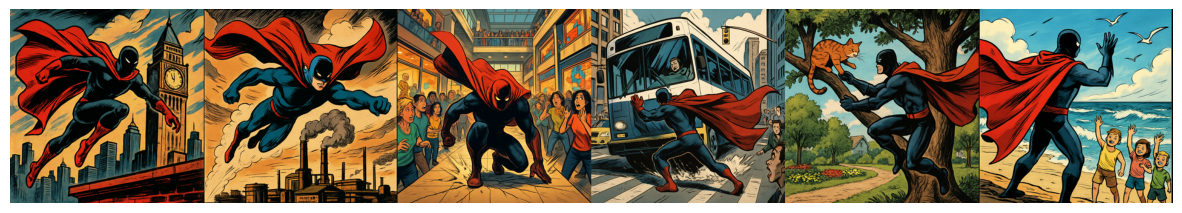

In [4]:
import subprocess
import sys

N_COMICS = 24
PANEL_HEIGHT = 320          # downscaled: attention cost is quadratic in image tokens
N_PANELS = 6

comics_dir = Path("comics")
if not comics_dir.exists():
    export = f"""
from datasets import load_dataset
from pathlib import Path
out = Path("comics"); out.mkdir(exist_ok=True)
for row in load_dataset("baulab/openai-comic-strips", split="train[:{N_COMICS}]"):
    folder = out / f"comic{{row['comic_id']}}"
    folder.mkdir(exist_ok=True)
    for k in range(1, {N_PANELS} + 1):
        row[f"panel_{{k}}"].save(folder / f"p{{k}}.png")
    (folder / "captions.txt").write_text(
        chr(10).join(row[f"caption_{{k}}"] for k in range(1, {N_PANELS} + 1)))
"""
    subprocess.run([sys.executable, "-c", export], check=True)

comics = sorted(comics_dir.iterdir())
print(f"{len(comics)} strips")

def build_strip(folder, height=PANEL_HEIGHT):
    """Stitch the six panels into one horizontal image."""
    panels = [Image.open(Path(folder) / f"p{k}.png").convert("RGB")
              for k in range(1, N_PANELS + 1)]
    panels = [p.resize((int(p.width * height / p.height), height), Image.LANCZOS) for p in panels]
    strip = Image.new("RGB", (sum(p.width for p in panels), height))
    x = 0
    for panel in panels:
        strip.paste(panel, (x, 0))
        x += panel.width
    return strip

example = build_strip(comics[0])
plt.figure(figsize=(15, 2.6))
plt.imshow(example)
plt.axis("off")
plt.show()

## Which image token is which panel?

Qwen3-VL turns the image into a grid of patches and then merges each $2\times2$ block, so the
language model sees an $(H/2) \times (W/2)$ grid flattened row-major. A token's column in that
grid tells you which panel it came from — panels occupy contiguous column ranges.

In [5]:
ORDINALS = ["first", "second", "third", "fourth", "fifth", "sixth"]

def query_prompt(panel):
    return ("Look carefully at this six-panel comic strip. "
            f"What is happening in the {ORDINALS[panel]} panel from the left? Answer briefly.")

def encode(image, text):
    messages = [{"role": "user", "content": [{"type": "image", "image": image},
                                             {"type": "text", "text": text}]}]
    return processor.apply_chat_template([messages], tokenize=True, add_generation_prompt=True,
                                         return_dict=True, return_tensors="pt")

def panel_layout(inputs):
    """Image-token positions in the sequence, and which panel each one belongs to."""
    ids = inputs["input_ids"][0].tolist()
    positions = [i for i, token in enumerate(ids) if token == IMAGE_TOKEN_ID]
    _, grid_h, grid_w = inputs["image_grid_thw"][0].tolist()
    rows, columns = grid_h // MERGE, grid_w // MERGE
    column_of = np.arange(rows * columns) % columns
    edges = np.linspace(0, columns, N_PANELS + 1)
    panel_of = np.clip(np.searchsorted(edges, column_of, side="right") - 1, 0, N_PANELS - 1)
    return positions, panel_of, (rows, columns)

probe_inputs = encode(example, query_prompt(2))
positions, panel_of, (rows, columns) = panel_layout(probe_inputs)
print(f"sequence length      : {probe_inputs['input_ids'].shape[1]}")
print(f"image tokens         : {len(positions)} (positions {positions[0]}..{positions[-1]})")
print(f"language-model grid  : {rows} x {columns}, {columns // N_PANELS} columns per panel")

sequence length      : 633
image tokens         : 600 (positions 4..603)
language-model grid  : 10 x 60, 10 columns per panel


## Discovering the gaze heads

The gaze score of head $(\ell, h)$ is the attention mass the **final prompt token** — the one
about to start the answer — puts on panel $k$'s image tokens, when the question asked about
panel $k$, averaged over panels and strips.

The mass is kept **raw**, not renormalised across panels. That matters: a head that ignores the
image entirely would still look perfectly diagonal after normalising, but scores ~0 raw. A head
only ranks highly if it both attends to the image *and* concentrates on the queried panel.

One forward pass per (strip, panel). No training, no labels.

In [6]:
DISCOVERY_STRIPS = 15

def attention_from_last_token(inputs):
    """[n_layers, n_heads, seq] — where the final prompt token looks, per head."""
    with torch.no_grad(), model.trace(inputs, output_attentions=True):
        per_layer = nnsight.save([])
        for layer in range(N_LAYERS):
            per_layer.append(model.output.attentions[layer][0, :, -1, :].detach().float().cpu())
    return torch.stack(list(per_layer)).numpy()

confusion = np.zeros((N_LAYERS, N_HEADS, N_PANELS, N_PANELS))   # queried x attended
for folder in comics[:DISCOVERY_STRIPS]:
    strip = build_strip(folder)
    for queried in range(N_PANELS):
        inputs = encode(strip, query_prompt(queried))
        positions, panel_of, _ = panel_layout(inputs)
        attention = attention_from_last_token(inputs)
        image_attention = attention[:, :, positions[0]:positions[0] + len(panel_of)]
        onehot = np.zeros((len(panel_of), N_PANELS))
        onehot[np.arange(len(panel_of)), panel_of] = 1.0
        confusion[:, :, queried, :] += np.einsum("lht,tr->lhr", image_attention, onehot)

confusion /= DISCOVERY_STRIPS
gaze_score = np.einsum("lhkk->lh", confusion) / N_PANELS        # the diagonal
print(f"{DISCOVERY_STRIPS * N_PANELS} forward passes, {N_LAYERS * N_HEADS} heads scored")

90 forward passes, 1152 heads scored


In [7]:
ranking = np.argsort(-gaze_score.flatten())
top_heads = [(int(i // N_HEADS), int(i % N_HEADS)) for i in ranking[:100]]

print("strongest gaze heads")
for i in ranking[:8]:
    print(f"   layer {i // N_HEADS:>2}  head {i % N_HEADS:<2}   {gaze_score.flatten()[i]:.3f}")
print(f"\nmedian head {np.median(gaze_score):.4f}   best {gaze_score.max():.3f}"
      f"   ratio {gaze_score.max() / np.median(gaze_score):.0f}x")

strongest gaze heads
   layer 24  head 13   0.563
   layer 24  head 29   0.560
   layer 21  head 11   0.548
   layer 23  head 28   0.547
   layer 24  head 23   0.544
   layer 23  head 10   0.537
   layer 21  head 18   0.503
   layer 23  head 30   0.437

median head 0.0127   best 0.563   ratio 44x


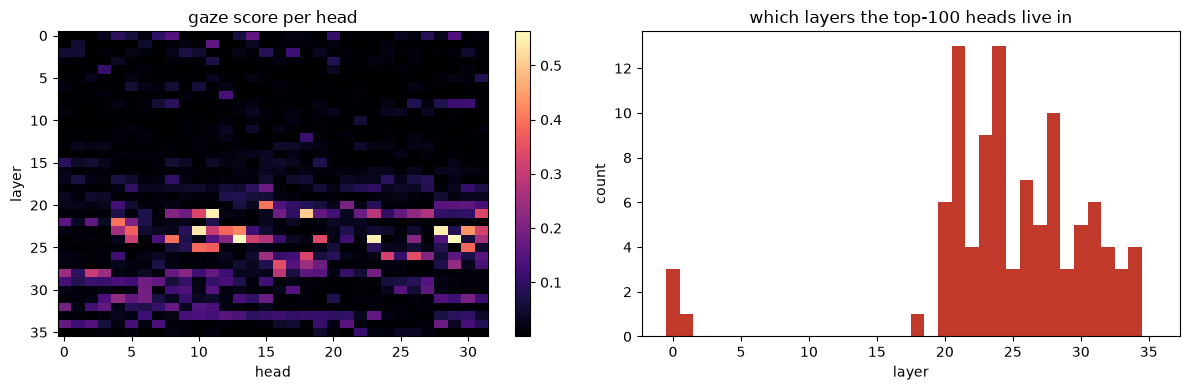

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(gaze_score, aspect="auto", cmap="magma")
axes[0].set(xlabel="head", ylabel="layer", title="gaze score per head")
plt.colorbar(im, ax=axes[0])

selected = np.array([[layer, head] for layer, head in top_heads])
axes[1].hist(selected[:, 0], bins=np.arange(N_LAYERS + 1) - 0.5, color="#c0392b")
axes[1].set(xlabel="layer", ylabel="count", title="which layers the top-100 heads live in")
plt.tight_layout()
plt.show()

The heads are sparse and they are localised: a handful of heads score far above the rest, and
they sit in a narrow band of middle-to-late layers. Everything else in the model scores near
zero.

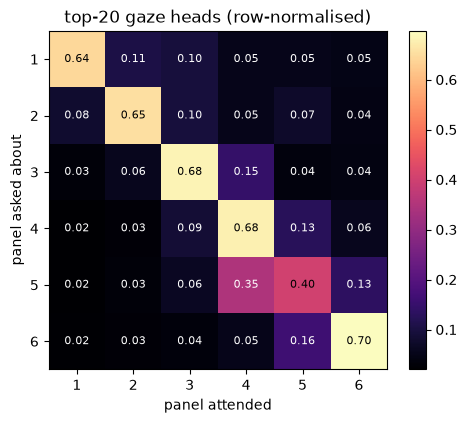

In [9]:
matrix = confusion[selected[:20, 0], selected[:20, 1]].mean(0)
matrix = matrix / matrix.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4.2))
im = ax.imshow(matrix, cmap="magma")
ax.set(xlabel="panel attended", ylabel="panel asked about",
       xticks=range(N_PANELS), yticks=range(N_PANELS),
       xticklabels=range(1, N_PANELS + 1), yticklabels=range(1, N_PANELS + 1),
       title="top-20 gaze heads (row-normalised)")
for i in range(N_PANELS):
    for j in range(N_PANELS):
        ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center",
                color="white" if matrix[i, j] < 0.4 else "black", fontsize=8)
plt.colorbar(im)
plt.tight_layout()
plt.show()

Ask about panel $k$, and these heads look at panel $k$. The diagonal is the whole finding, and
nothing was trained to produce it — this is where the model already looks.

## Steering: pointing the heads somewhere else

Now the intervention. An additive attention mask is added to the attention logits before the
softmax, so writing into it is the cleanest possible way to bias attention:

$$\text{logits}_{h} \leftarrow \text{logits}_{h} + b_h, \qquad b_h = \begin{cases} +\beta & \text{target panel's image tokens} \\ -\beta & \text{other image tokens} \\ 0 & \text{everything else} \end{cases}$$

The mask Qwen3-VL passes is `[batch, 1, q, k]` — broadcast over heads. Adding a `[1, n_heads, 1, k]`
row turns it per-head, so only the chosen heads are redirected and every other head in the same
layer sees the mask it would have seen.

Two things to get right in `nnsight`:

- **Touch layers in ascending order.** Reading `self_attn.inputs` for layer 21 after layer 24
  raises `OutOfOrderError` — the forward pass has already gone by.
- **Build the bias once, not per head per step.** A Python loop over 100 heads inside a
  generation loop is what turns a two-second run into a two-minute one.

In [10]:
BIAS = 10_000.0            # the paper's value: large enough to saturate the softmax
MAX_NEW_TOKENS = 48

def bias_rows(heads, target_positions, other_positions, prompt_length):
    """One [n_heads, prompt_length] additive row per layer that has a selected head."""
    by_layer = {}
    for layer, head in heads:
        by_layer.setdefault(layer, []).append(head)
    rows = {}
    for layer, head_list in by_layer.items():
        row = torch.zeros(N_HEADS, prompt_length, dtype=torch.bfloat16, device=model.device)
        index = torch.tensor(head_list, device=model.device)
        row[index[:, None], torch.tensor(target_positions, device=model.device)[None, :]] = BIAS
        row[index[:, None], torch.tensor(other_positions, device=model.device)[None, :]] = -BIAS
        rows[layer] = row
    return rows

def describe(inputs, heads=None, target=None, max_new_tokens=MAX_NEW_TOKENS):
    """Generate an answer, optionally holding `heads` on `target` panel."""
    rows = None
    if heads is not None:
        positions, panel_of, _ = panel_layout(inputs)
        on_target = [positions[i] for i in np.where(panel_of == target)[0]]
        elsewhere = [positions[i] for i in np.where(panel_of != target)[0]]
        rows = bias_rows(heads, on_target, elsewhere, inputs["input_ids"].shape[1])

    with torch.no_grad(), model.generate(inputs, max_new_tokens=max_new_tokens,
                                         do_sample=False) as tracer:
        generated = nnsight.save([])
        for _ in tracer.iter[:max_new_tokens]:
            if rows is not None:
                for layer in sorted(rows):                    # ascending = forward order
                    attention = language_layers[layer].self_attn
                    args, kwargs = attention.inputs
                    mask = kwargs["attention_mask"]
                    width = mask.shape[-1]
                    row = rows[layer]
                    if width > row.shape[1]:                  # pad over generated positions
                        row = torch.cat([row, torch.zeros(N_HEADS, width - row.shape[1],
                                                          dtype=row.dtype, device=row.device)], 1)
                    kwargs["attention_mask"] = mask + row[None, :, None, :width]
                    attention.inputs = (args, kwargs)
            generated.append(model.output.logits[0, -1].argmax())

    return processor.tokenizer.decode([t.item() for t in generated],
                                      skip_special_tokens=True).strip()

The question is deliberately ambiguous — it never says *which* panel:

In [11]:
AMBIGUOUS = "What is happening in this panel of the comic strip? Answer in one sentence."

strip = build_strip(comics[0])
inputs = encode(strip, AMBIGUOUS)
captions = (comics[0] / "captions.txt").read_text().split("\n")

print("unsteered:")
print(f"   {describe(inputs)}\n")
print("gaze heads held on each panel in turn:")
for panel in range(N_PANELS):
    print(f"   panel {panel + 1} -> {describe(inputs, top_heads, panel)}")
print("\nground-truth captions:")
for panel, caption in enumerate(captions):
    print(f"   panel {panel + 1}: {caption}")

unsteered:


   A superhero with a red cape is shown in various action scenes, including flying over London, saving people from a bus, rescuing a cat from a tree, and standing heroically on a beach with children.

gaze heads held on each panel in turn:


   panel 1 -> A superhero is seen in various scenes, including a battle with a villain, a confrontation with a giant, and a dramatic display of power, all while maintaining a heroic presence.


   panel 2 -> A superhero flies through the air, battles a villain, and saves a city from a flying bomb, while a superhero flies through the air, battles a villain, and saves a city from a flying bomb, while a superhero flies through the air


   panel 3 -> A group of people are gathered around a woman who is being attacked by a group of people, while a woman in a red dress is standing in the middle of the scene.


   panel 4 -> A bus driver is being pulled out of his vehicle by a truck driver, while a truck driver is being pulled out of his vehicle by a bus driver, as a result of a collision between a bus and a truck.


   panel 5 -> A family tree is being used as a treehouse for a cat, while a man is sitting on a tree branch with a tree.


   panel 6 -> A child is being chased by a shark, but the child is not scared because they are not afraid of the shark.

ground-truth captions:
   panel 1: The superhero leaps off a rooftop, city skyline in the background, with a large clock tower prominently in view.
   panel 2: The superhero flies through the air, an industrial park beneath them with smokestacks puffing steam.
   panel 3: The superhero lands in an overflowing shopping mall, storefronts filled with people and colorful displays.
   panel 4: The superhero stops a runaway bus, amidst a city's busy intersection with halted traffic and surprised pedestrians.
   panel 5: The superhero helps a cat stuck in a tree, a quaint suburban park setting with flower beds.
   panel 6: The superhero waves to children from a beach, with ocean waves and seagulls in the sky.


One image, one question, six different answers — and each one is about the panel the heads were
pointed at.

## Does it hold up, and is it really these heads?

Two controls decide whether this is the gaze heads or just any large perturbation:

- **random non-gaze heads** — the same number of heads, drawn from the bottom half of the
  ranking. If steering works through generic disruption, these should work too.
- **all heads** — every head in the model. Redirecting everything should destroy the generation
  rather than retarget it.

For scoring, the paper uses an LLM judge. Here the strips come with ground-truth captions, so a
cheap stand-in is available: match the answer to whichever caption shares the most
rare words with it. Cruder than a judge, and it's the weakest link in this notebook — but it is
reproducible and needs no API key.

In [12]:
STOPWORDS = set("""a an the is are was were be been being of in on at to and or with by from for
this that these those it its his her their they he she we you as while but into over under near
above below there here what happening panel comic strip scene shown seen sentence one""".split())

def content_words(text):
    return [w for w in re.findall(r"[a-z]+", text.lower()) if w not in STOPWORDS and len(w) > 2]

def judge(answer, captions):
    """Pick the caption sharing the most rare words with the answer (-1 if nothing matches)."""
    caption_words = [set(content_words(c)) for c in captions]
    document_freq = {w: sum(w in c for c in caption_words) for w in set().union(*caption_words)}
    scores = [sum(math.log(1 + N_PANELS / document_freq[w])
                  for w in content_words(answer) if w in words)
              for words in caption_words]
    return int(np.argmax(scores)) if max(scores) > 0 else -1

rng = np.random.default_rng(0)
weak = ranking[len(ranking) // 2:]
random_heads = [(int(i // N_HEADS), int(i % N_HEADS))
                for i in rng.choice(weak, 100, replace=False)]
all_heads = [(l, h) for l in range(N_LAYERS) for h in range(N_HEADS)]

held_out = comics[DISCOVERY_STRIPS:DISCOVERY_STRIPS + 4]      # never used for discovery
conditions = {"top-100 gaze heads": top_heads,
              "100 random non-gaze": random_heads,
              "all heads": all_heads}

results = {}
for name, heads in conditions.items():
    hits = total = degenerate = 0
    for folder in held_out:
        inputs = encode(build_strip(folder), AMBIGUOUS)
        captions = (folder / "captions.txt").read_text().split("\n")
        for target in range(N_PANELS):
            answer = describe(inputs, heads, target)
            degenerate += len(set(content_words(answer))) < 4
            hits += judge(answer, captions) == target
            total += 1
    results[name] = (hits / total, degenerate / total)
    print(f"{name:22s} accuracy {hits / total:.2f}   degenerate {degenerate / total:.0%}")
print(f"{'chance':22s} accuracy {1 / N_PANELS:.2f}")

top-100 gaze heads     accuracy 0.54   degenerate 8%


100 random non-gaze    accuracy 0.04   degenerate 0%


all heads              accuracy 0.00   degenerate 100%
chance                 accuracy 0.17


The three conditions separate cleanly, and they say the effect is specific to these heads:

- **top-100 gaze heads: 0.54** against a chance rate of 0.17 — the answer follows the panel we
  point them at, three times more often than picking at random.
- **100 random non-gaze heads: 0.04.** The same intervention, the same strength, the same number
  of heads — and *below* chance. Whatever is happening is not generic perturbation.
- **all 1152 heads: 0.00, and 100% of generations degenerate.** Redirecting everything destroys
  the model rather than retargeting it, which is the point: the lever is a small subset, not
  attention in general.

The paper reports ~80% for its gaze-head condition; 0.54 here is lower, and the two most likely
reasons are that this runs a 4B model rather than their 8B, and that the judge is rare-word
overlap rather than an LLM asked to pick a panel. The lexical judge is unforgiving of a correct
answer phrased in words the caption happens not to use — panel 6 above ("a child is being chased
by a shark" for a beach scene) is exactly the kind of case it scores as a miss.

What survives the scaling down is the shape of the result: a sparse, findable set of heads carries
the choice of what to describe, and nothing else does.

## Conclusion

🎉 A vision-language model's answer about "which part of this picture" is routed through a small,
findable set of attention heads. Finding them takes one forward pass per query and no training;
once found, a single pre-softmax bias on those heads decides what the model describes.

On the `nnsight` side the whole intervention is one idea: an additive attention mask is added to
the logits before the softmax, so writing into `self_attn.inputs`'s `attention_mask` kwarg *is*
steering attention — no custom attention implementation, no monkey-patching. The two things that
actually cost time were ordering (layers ascending, or `OutOfOrderError`) and building the bias
once instead of per head per step.

Related: [Concept Attention](concept-attention.ipynb) for reading a diffusion
transformer's attention rather than steering it,
[The Logit Lens Over Image Tokens](vlm-logit-lens.ipynb) for the same model family's image
tokens read as language, and
[Cross-Attention Ablation](../tutorials/vision/cross-attention-ablation.ipynb) for the ablation
equivalent.

## References

- Gandikota & Bau, [*Gaze Heads: How VLMs Look at What They Describe*](https://arxiv.org/abs/2606.14703), 2026 — [project page](https://gaze.baulab.info), [code](https://github.com/rohitgandikota/gaze-heads)
- [`baulab/openai-comic-strips`](https://huggingface.co/datasets/baulab/openai-comic-strips) — the 500-strip dataset used here
- Kobayashi et al., [*Attention is Not Only a Weight*](https://arxiv.org/abs/2004.10102), EMNLP 2020 — value-norm weighted attention, used in the paper's trajectory analysis